## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack
import os
import random

## Data preprocessing

In [8]:
def preprocess_data(file_path):
    """
    Preprocess the product dataset for recommender system.
    
    Parameters:
    file_path (str): Path to the dataset file
    
    Returns:
    pd.DataFrame: Preprocessed dataframe
    """
    # Read dataset
    df = pd.read_csv(file_path, sep='\t')
    
    # Select relevant columns
    df = df[['Uniq Id', 'Product Id', 'Product Rating', 'Product Reviews Count', 
             'Product Category', 'Product Brand', 'Product Name', 
             'Product Image Url', 'Product Description', 'Product Tags']]
    
    # Fill missing values
    df['Product Rating'].fillna(0, inplace=True)
    df['Product Reviews Count'].fillna(0, inplace=True)
    df['Product Category'].fillna('', inplace=True)
    df['Product Brand'].fillna('', inplace=True)
    df['Product Description'].fillna('', inplace=True)
    df['Product Tags'].fillna('', inplace=True)
    
    # Rename columns to shorter names
    column_name_mapping = {
        'Uniq Id': 'ID',
        'Product Id': 'ProdID',
        'Product Rating': 'Rating',
        'Product Reviews Count': 'ReviewCount',
        'Product Category': 'Category',
        'Product Brand': 'Brand',
        'Product Name': 'Name',
        'Product Image Url': 'ImageURL',
        'Product Description': 'Description',
        'Product Tags': 'Tags'
    }
    df.rename(columns=column_name_mapping, inplace=True)
    
    # Create content feature by combining text fields
    df['Content'] = df['Name'] + ' ' + df['Brand'] + ' ' + df['Category'] + ' ' + df['Description'] + ' ' + df['Tags']
    
    print(f"Dataset loaded and preprocessed: {df.shape[0]} products with {df.shape[1]} features")
    return df

In [9]:
df=preprocess_data('G:\\Projects\\smart e-commerce project\\data\\marketing_sample_for_walmart_com-walmart_com_product_review__20200701_20201231__5k_data.tsv')

Dataset loaded and preprocessed: 5000 products with 11 features


In [10]:
df.head()

,ID,ProdID,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags,Content
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,0.0,0.0,Premium Beauty > Premium Makeup > Premium Nail...,OPI,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...","OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,0.0,0.0,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,"Nice n Easy Permanent Color, 111 Natural Mediu...",https://i5.walmartimages.com/asr/9c8e42e4-13a5...,Pack of 3 Pack of 3 for the UPC: 381519000201 ...,"Nice 'n Easy Permanent Color, 111 Natural Medi...","Nice n Easy Permanent Color, 111 Natural Mediu..."
2,8d4d0330178d3ed181b15a4102b287f2,8a4fe5d9c7a6ed26cc44d785a454b124,4.5,29221.0,Beauty > Hair Care > Hair Color > Permanent Ha...,Clairol,Clairol Nice N Easy Permanent Color 7/106A Nat...,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,This Clairol Nice N Easy Permanent Color gives...,Clairol Nice 'N Easy Permanent Color 7/106A Na...,Clairol Nice N Easy Permanent Color 7/106A Nat...
3,fddc4df45b35efd886794b261f730c51,03b5fb878a33eadff8b033419eab9669,0.0,0.0,Beauty > Makeup > Lip,Kokie Cosmetics,"Kokie Professional Matte Lipstick, Hot Berry, ...",https://i5.walmartimages.com/asr/25b4b467-bc61...,Calling all matte lip lovers! Indulge in our r...,"Kokie Professional Matte Lipstick, Hot Berry, ...","Kokie Professional Matte Lipstick, Hot Berry, ..."
4,0990cf89a59ca6a0460349a3e4f51d42,ce3d761e57d6ccad80619297b5b1bcbc,0.0,131.0,Seasonal > Stock Up Essentials > Personal Care...,Gillette,"Gillette TRAC II Plus Razor Blade Refills, Fit...",https://i5.walmartimages.com/asr/1a2ebb06-cd01...,"In 1971, Gillette introduced the Trac II razor...","Gillette TRAC II Plus Razor Blade Refills, Fit...","Gillette TRAC II Plus Razor Blade Refills, Fit..."


## EDA

In [11]:
df.shape

(5000, 11)

In [12]:
df.isna().sum()

ID             0
ProdID         0
Rating         0
ReviewCount    0
Category       0
Brand          0
Name           0
ImageURL       0
Description    0
Tags           0
Content        0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           5000 non-null   object 
 1   ProdID       5000 non-null   object 
 2   Rating       5000 non-null   float64
 3   ReviewCount  5000 non-null   float64
 4   Category     5000 non-null   object 
 5   Brand        5000 non-null   object 
 6   Name         5000 non-null   object 
 7   ImageURL     5000 non-null   object 
 8   Description  5000 non-null   object 
 9   Tags         5000 non-null   object 
 10  Content      5000 non-null   object 
dtypes: float64(2), object(9)
memory usage: 429.8+ KB


In [14]:
df.duplicated().sum()

0

Text(0, 0.5, 'Count')

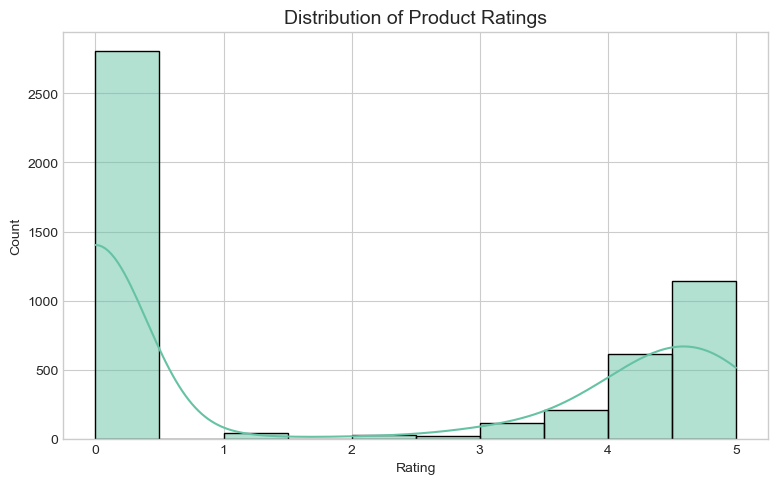

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
    
# Create a figure with subplots
fig = plt.figure(figsize=(20, 18))
    
# 1. Distribution of product ratings
plt.subplot(3, 2, 1)
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title('Distribution of Product Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')

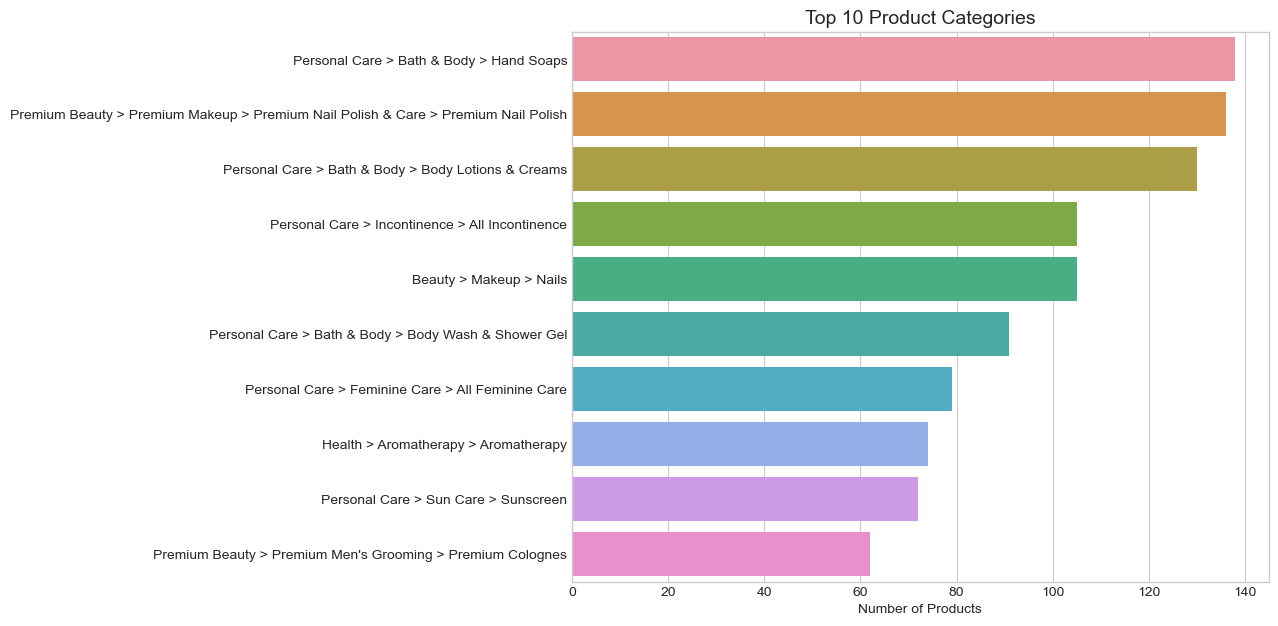

In [22]:
fig = plt.figure(figsize=(20, 18))

# 2. Top categories by number of products
plt.subplot(3, 2, 2)
category_counts = df['Category'].value_counts().head(10)
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title('Top 10 Product Categories', fontsize=14)
plt.xlabel('Number of Products')
plt.tight_layout()

Text(0.5, 0, 'Average Rating')

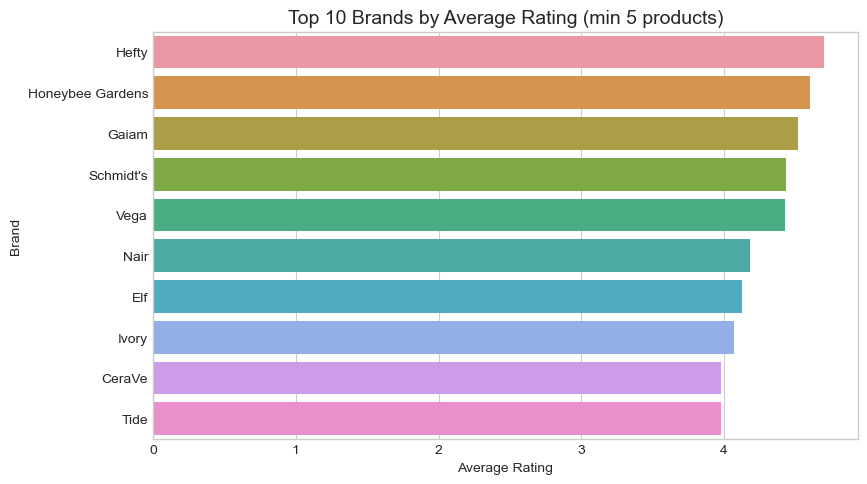

In [25]:
fig = plt.figure(figsize=(20, 18))

plt.subplot(3, 2, 4)
brand_ratings = df.groupby('Brand').agg({
        'Rating': ['mean', 'count']
    })
brand_ratings.columns = ['Avg Rating', 'Count']
top_brands = brand_ratings[brand_ratings['Count'] >= 5].sort_values('Avg Rating', ascending=False).head(10)
sns.barplot(x=top_brands['Avg Rating'], y=top_brands.index)
plt.title('Top 10 Brands by Average Rating (min 5 products)', fontsize=14)
plt.xlabel('Average Rating')

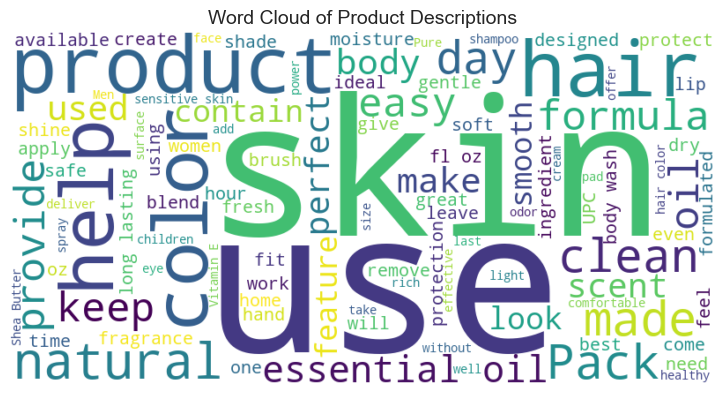

In [26]:
fig = plt.figure(figsize=(20, 18))


try:
    from wordcloud import WordCloud
    plt.subplot(3, 2, 5)
        
    # Combine all descriptions
    all_descriptions = ' '.join(df['Description'].dropna())
        
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, 
                            background_color='white',
                            max_words=100).generate(all_descriptions)
        
    # Display the word cloud
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Product Descriptions', fontsize=14)
except ImportError:
    plt.subplot(3, 2, 5)
    plt.text(0.5, 0.5, "WordCloud package not available.\nInstall with: pip install wordcloud", 
                ha='center', va='center', fontsize=14)
    plt.axis('off')

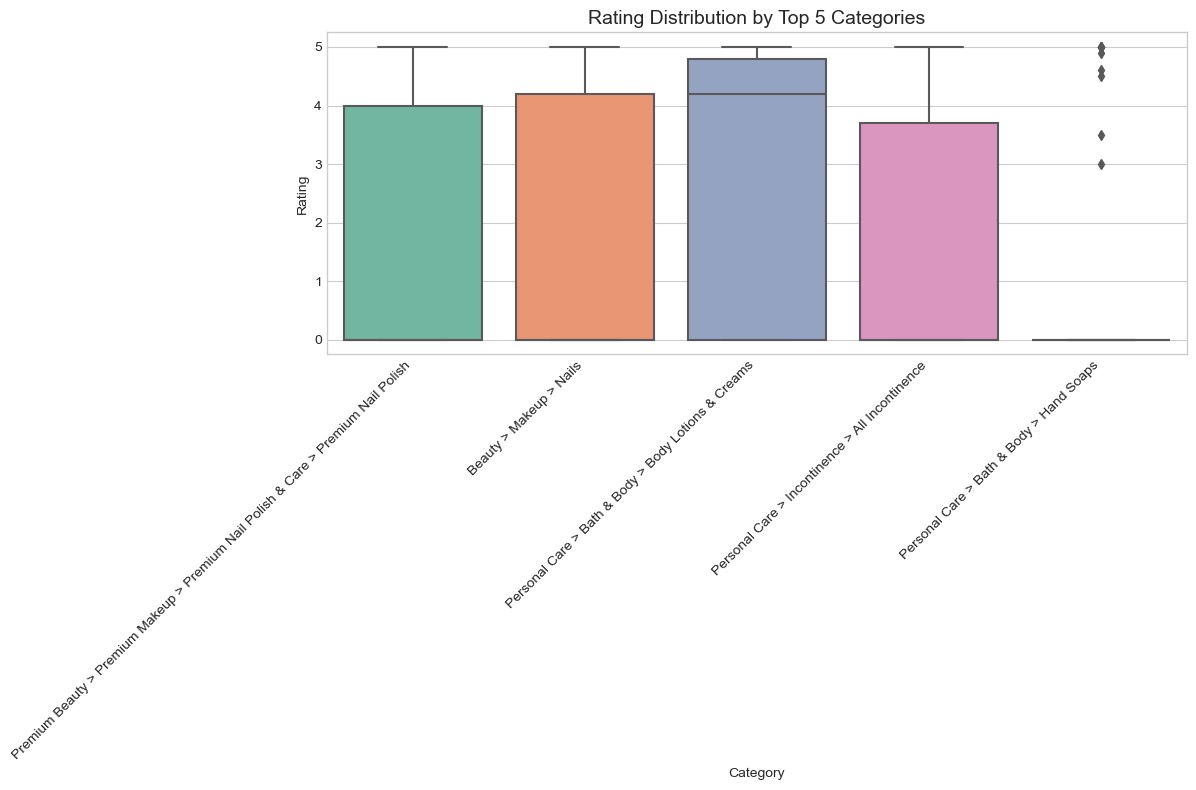

In [ ]:
plt.figure(figsize=(12, 8))

top_5_categories = df['Category'].value_counts().head(5).index
category_df = df[df['Category'].isin(top_5_categories)]
    
sns.boxplot(x='Category', y='Rating', data=category_df)
plt.title('Rating Distribution by Top 5 Categories', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## clean text and create tags

In [33]:
import re
import warnings
import time
from collections import Counter
import spacy

In [36]:
import re
import time
from collections import Counter

import pandas as pd

# Try to import spaCy and load the English model
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
    ALL_STOP_WORDS = spacy.lang.en.stop_words.STOP_WORDS
    print("spaCy loaded, advanced NLP available.")
except (ImportError, OSError):
    SPACY_AVAILABLE = False
    # Fallback: simple stop-word list (augment as needed)
    ALL_STOP_WORDS = {
        "the", "and", "is", "in", "to", "of", "for", "on", "with", "a", "an"
    }
    print("spaCy not available, falling back to simple tokenization.")

def clean_text_and_create_tags(df):
    """
    Clean text data and create enhanced tags from product information.

    Parameters:
    df (pd.DataFrame): DataFrame with product data. Must contain columns
                       ['Name', 'Category', 'Brand', 'Description', 'Tags']

    Returns:
    pd.DataFrame: DataFrame with additional columns:
                  - Raw_<col> backups
                  - 'Tags': weighted, filtered tag string
                  - 'Content': combined field for TF-IDF
    """
    print("Cleaning text and generating enhanced tags...")
    start_time = time.time()

    def clean_and_extract_tags(text, min_token_length=3, max_token_length=20):
        if not isinstance(text, str) or not text.strip():
            return []

        # Lowercase & remove non-alphanumeric (except whitespace)
        text = re.sub(r"[^\w\s]", " ", text.lower())

        tags = []
        if SPACY_AVAILABLE:
            doc = nlp(text)
            for token in doc:
                t = token.text
                if (
                    t not in ALL_STOP_WORDS and
                    token.is_alpha and
                    not t.isdigit() and
                    min_token_length <= len(t) <= max_token_length
                ):
                    if token.pos_ in ["NOUN", "PROPN"]:
                        tags.append(t)
                    elif token.pos_ == "ADJ" and token.i + 1 < len(doc) and doc[token.i + 1].pos_ in ["NOUN", "PROPN"]:
                        tags.append(f"{t}_{doc[token.i + 1].text}")

            # Include certain named entities
            for ent in doc.ents:
                if ent.label_ in ["PRODUCT", "ORG", "PERSON", "GPE", "LOC", "WORK_OF_ART"]:
                    clean_ent = re.sub(r"[^\w\s]", " ", ent.text.lower()).strip()
                    if min_token_length <= len(clean_ent) <= max_token_length * 2:
                        tags.append(clean_ent.replace(" ", "_"))
        else:
            for token in text.split():
                if (
                    token not in ALL_STOP_WORDS and
                    token.isalnum() and
                    not token.isdigit() and
                    min_token_length <= len(token) <= max_token_length
                ):
                    tags.append(token)

        return tags

    # Columns to process
    cols = ["Name", "Category", "Brand", "Description", "Tags"]

    # Backup raw columns
    for col in cols:
        df[f"Raw_{col}"] = df[col].astype(str)

    # Extract tags per column
    for col in cols:
        print(f"  → processing '{col}'")
        df[f"{col}_tags"] = df[f"Raw_{col}"].apply(clean_and_extract_tags)

    # Combine tags and dedupe while preserving order
    df["Enhanced_Tags"] = df.apply(
        lambda row: list(dict.fromkeys(
            tag for col in cols for tag in row[f"{col}_tags"]
        )),
        axis=1
    )

    # Count global frequencies
    all_tags = [t for tags in df["Enhanced_Tags"] for t in tags]
    tag_counter = Counter(all_tags)

    # Frequency thresholds
    min_freq = 2
    max_freq = len(df) * 0.5

    # Filter by frequency
    df["Important_Tags"] = df["Enhanced_Tags"].apply(
        lambda tags: [t for t in tags if min_freq <= tag_counter[t] <= max_freq]
    )

    # Turn into weighted string
    def weighted_str(tags):
        return " ".join(sorted(tags, key=lambda t: -tag_counter[t])) if tags else ""

    df["Tags"] = df["Important_Tags"].apply(weighted_str)

    # Build final content field
    df["Content"] = (
        df["Raw_Name"] + " " +
        df["Raw_Brand"] + " " +
        df["Raw_Category"] + " " +
        df["Tags"] + " " +
        df["Raw_Description"]
    )

    # Clean up intermediate columns
    to_drop = [f"{col}_tags" for col in cols] + ["Enhanced_Tags", "Important_Tags"]
    df.drop(columns=to_drop, inplace=True)

    elapsed = time.time() - start_time
    print(f"Done in {elapsed:.2f}s.")
    return df

spaCy loaded, advanced NLP available.


In [37]:
df= clean_text_and_create_tags(df)
df[["Name", "Tags", "Content"]].head()

Cleaning text and generating enhanced tags...
  → processing 'Name'
  → processing 'Category'
  → processing 'Brand'
  → processing 'Description'
  → processing 'Tags'
Done in 174.66s.


,Name,Tags,Content
0,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",beauty premium makeup bath nail polish premium...,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,"Nice n Easy Permanent Color, 111 Natural Mediu...",beauty pack color formula oil hair ingredients...,"Nice n Easy Permanent Color, 111 Natural Mediu..."
2,Clairol Nice N Easy Permanent Color 7/106A Nat...,beauty color hair home quality conditioner shi...,Clairol Nice N Easy Permanent Color 7/106A Nat...
3,"Kokie Professional Matte Lipstick, Hot Berry, ...",beauty color makeup lip application lipstick m...,"Kokie Professional Matte Lipstick, Hot Berry, ..."
4,"Gillette TRAC II Plus Razor Blade Refills, Fit...",skin personal_care pack use face gel essential...,"Gillette TRAC II Plus Razor Blade Refills, Fit..."
